# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\madha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Load daatset

In [2]:
df=pd.read_csv(r"C:\Users\madha\Downloads\archive\Mental_health.csv")
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


# text cleaning

In [5]:
df = df.dropna(subset=['status'])

df['statement'] = df['statement'].fillna("")

In [6]:
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words 
df['tokens'] = df['statement'].apply(clean_text)

# word cloud

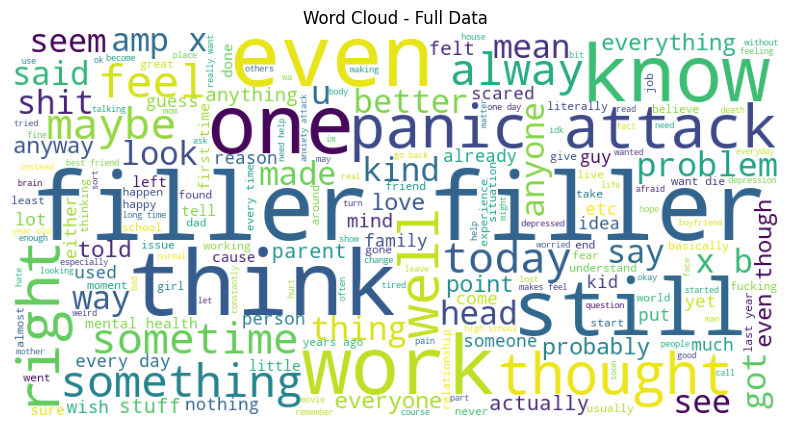

In [7]:
text = " ".join([" ".join(words) for words in df['tokens']])
wc = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud - Full Data")
plt.show()

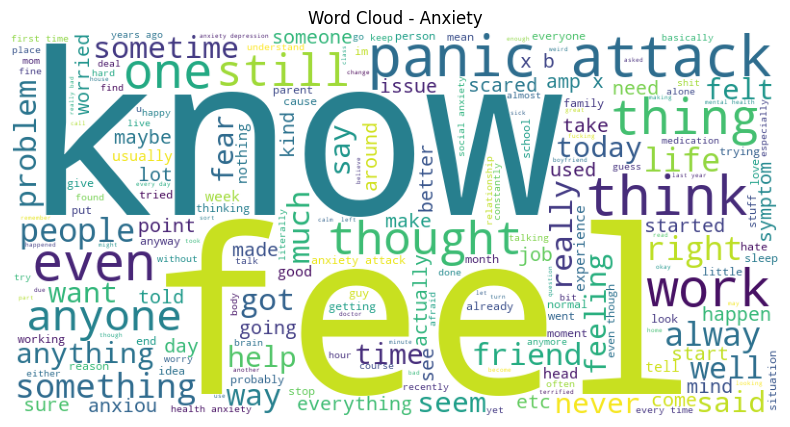

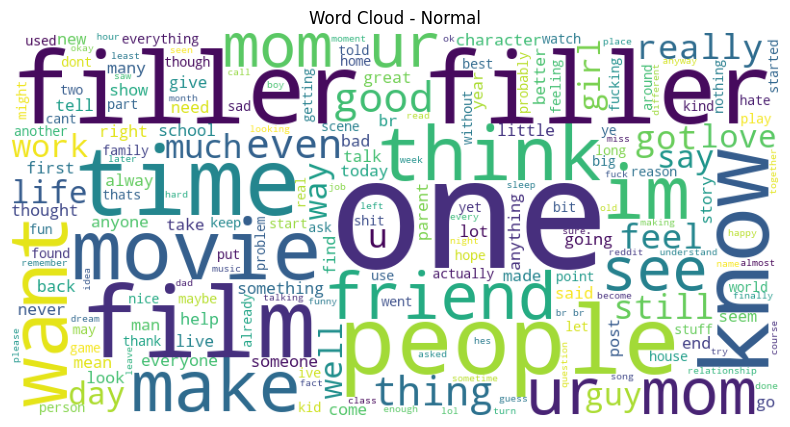

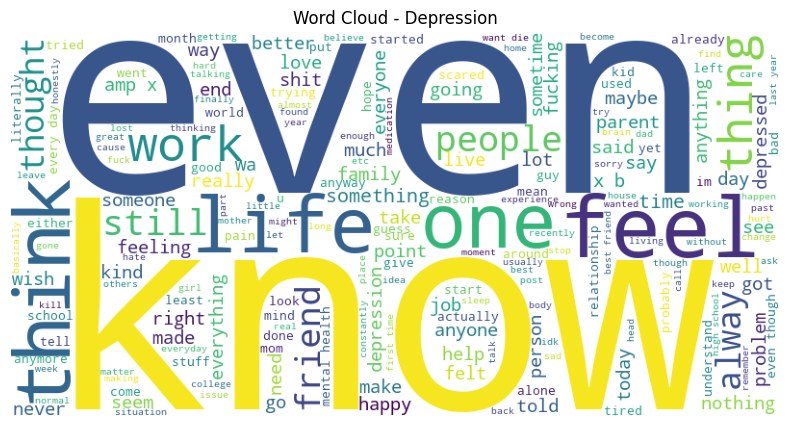

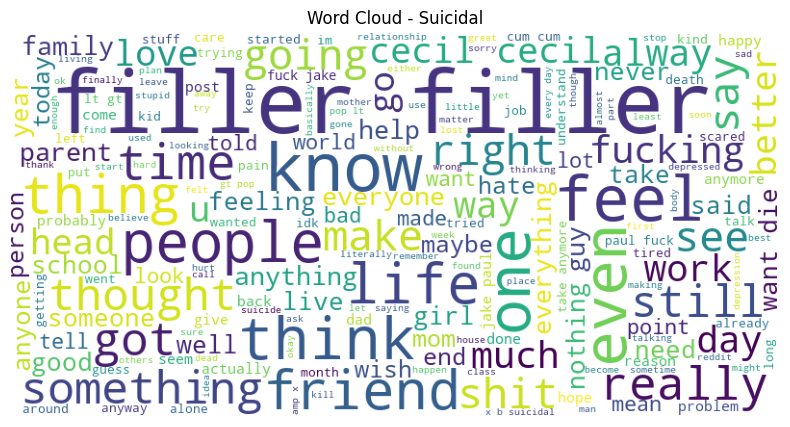

In [8]:
for label in df['status'].unique():
    text = " ".join([" ".join(words) for words in df[df['status']==label]['tokens']])
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Word Cloud - {label}")
    plt.show()

In [11]:
embeddings_index = {}
with open(r"C:\Desktop\OneDrive\Desktop\glove.6B\glove.6B.200d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector
print("Loaded %s word vectors" % len(embeddings_index))

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Desktop\\OneDrive\\Desktop\\glove.6B\\glove.6B.200d.txt'

In [12]:
embedding_dim = 200

In [13]:
def get_avg_vector(tokens):
    vectors = [embeddings_index[word] for word in tokens if word in embeddings_index]
    
    if len(vectors) == 0:
        return np.zeros(200)  
    
    return np.nan_to_num(np.mean(vectors, axis=0))  


X = np.vstack([get_avg_vector(tokens) for tokens in df['tokens']])
y = df['status']  

In [14]:
print(X.shape)

(197204, 200)


# train and test

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [17]:
y_pred = model.predict(X_test)

C:\Users\madha\anaconda3\Lib\site-packages\sklearn\naive_bayes.py:538: RuntimeWarning: divide by zero encountered in log
  n_ij = -0.5 * xp.sum(xp.log(2.0 * xp.pi * self.var_[i, :]))
C:\Users\madha\anaconda3\Lib\site-packages\sklearn\naive_bayes.py:540: RuntimeWarning: invalid value encountered in divide
  ((X - self.theta_[i, :]) ** 2) / (self.var_[i, :]), axis=1


# evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# prediction

In [ ]:
def predict_text(text):
    tokens = clean_text(text)
    vec = get_avg_vector(tokens).reshape(1, -1)
    return model.predict(vec)[0]
predict_text("I feel stress")

In [ ]:
with open(r"C:\Users\VARSHA SURA\Downloads\glove.6B\glove.6B.200d.txt", encoding="utf8") as f: